# Hillik: a consistent High-&ell; likelihood

[``Hillik``](#https://github.com/mtristram/hillik) is a CMB likelihood based on cross-power spectra which can accomodate spectra from different survey (Planck, SPT, ACT) within a common modelisation of the foreground residuals.\
The likelihood is a Gaussian approximation with a signal model including CMB, galactic emissions (dust), poisson noise (from unmasked point sources) and extra-galactic emissions (tSZ, CIB, kSZ, SZxCIB).\
Nuisance parameters (calibration, polar efficiency, T-E-B leakage, ...) are associated to each survey with the exact same treatment as in the original studies.

In [1]:
import MCtools
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains"
clth = read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = arange(len(clth[0]))

## Table Of Content
* [Each survey](#Each-survey)
* [Combination](#Combination)
* [Alens](#Alens)
* [Impact of Hillik](#Impact-of-Hillik)
* [Template tSZ](#Template-tSZ)
* [Template kSZ](#Template-kSZ)

## Each survey

In [2]:
runnames = ['hillik_plk','hillik_spt','hillik_act']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]

hillik_plk: 263583  179464  197081  196211 
hillik_spt: 822482  641454  614436  739384 
hillik_act: 859001  694859  854156  926618 


                         hillik_plk                 hillik_spt                 hillik_act
ombh2           =  0.022231 +/- 0.000210  |   0.023479 +/- 0.001864  |   0.021491 +/- 0.000647
omch2           =  0.119233 +/- 0.002030  |   0.113043 +/- 0.015402  |   0.131705 +/- 0.007546
theta           =  1.040778 +/- 0.000464  |   1.039671 +/- 0.006315  |   1.040766 +/- 0.001430
tau             =  0.056628 +/- 0.006561  |   0.054437 +/- 0.006725  |   0.055260 +/- 0.007101
ns              =  0.963211 +/- 0.005563  |   0.979379 +/- 0.021918  |   0.988789 +/- 0.010381
logA            =  3.043038 +/- 0.014406  |   2.983800 +/- 0.080656  |   3.066664 +/- 0.055347


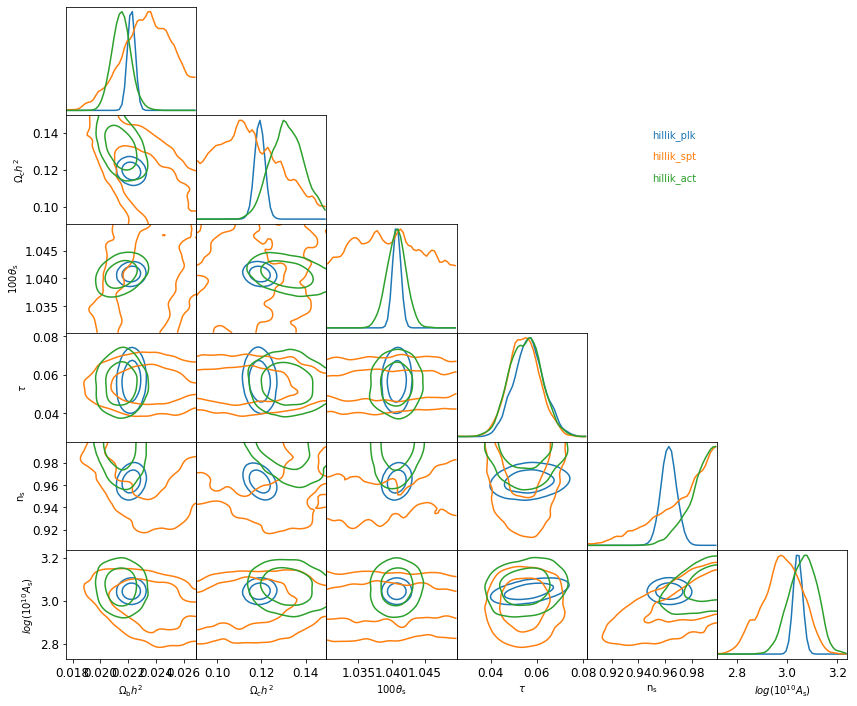

In [3]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)
print( "%35s %26s %26s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

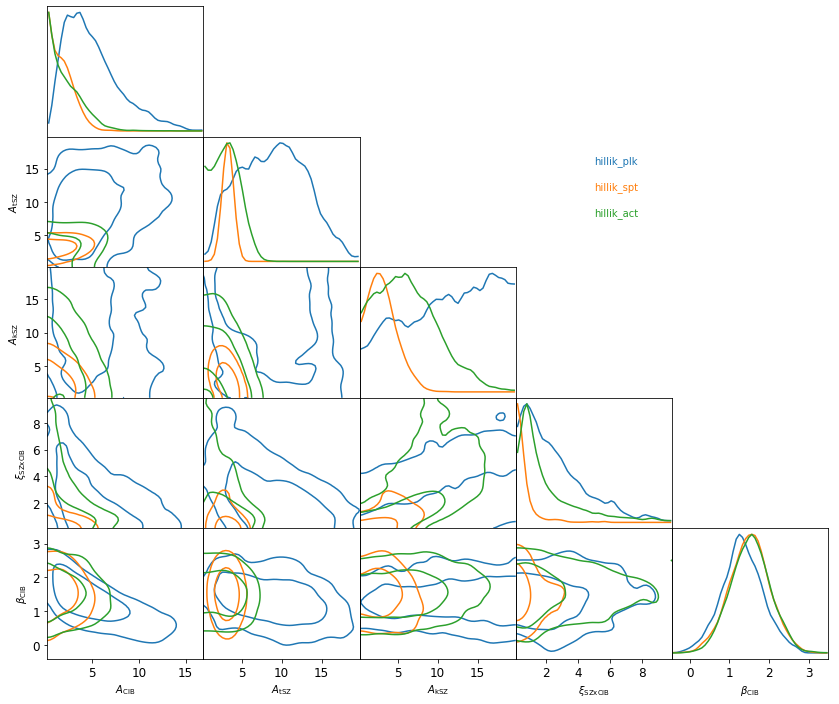

In [4]:
#extra-galactic fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Combination

In [2]:
runnames = ['hillik_plk','hillik_plkspt','hillik_plkact','hillik_plksptact']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]

hillik_plk: 263583  179464  197081  196211 
hillik_plkspt: 499286  493104  434884  484491 
hillik_plkact: 615618  734300  510025  596834 
hillik_plksptact: 880813  1017840  939259  693479 


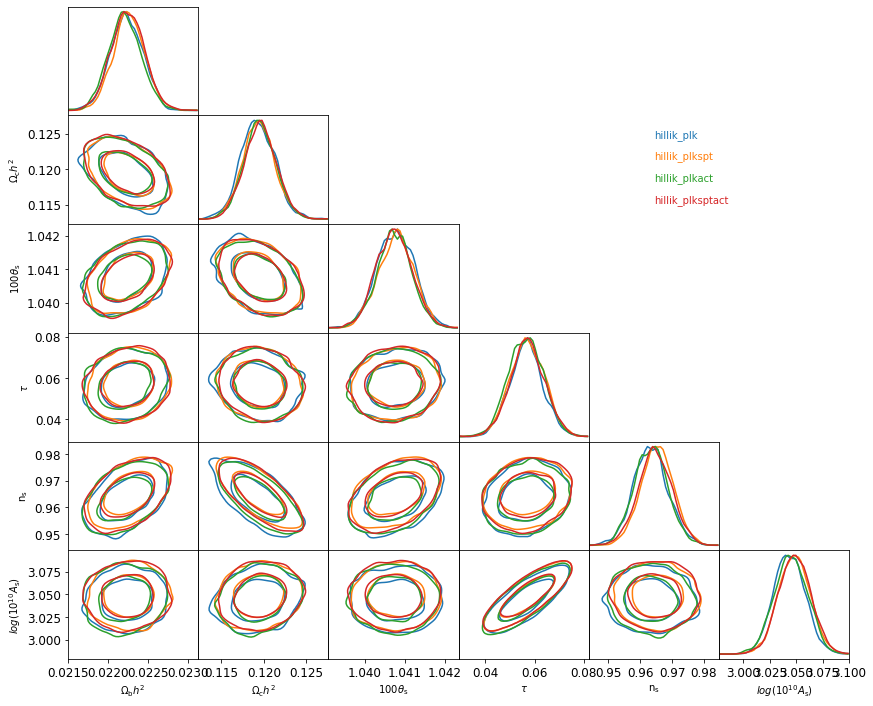

In [3]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

In [4]:
print( "%35s %27s %27s %27s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

                         hillik_plk               hillik_plkspt               hillik_plkact            hillik_plksptact
ombh2           =  0.022234 +/- 0.000210  |   0.022260 +/- 0.000195  |   0.022207 +/- 0.000208  |   0.022248 +/- 0.000210
omch2           =  0.119226 +/- 0.002041  |   0.119371 +/- 0.001880  |   0.119495 +/- 0.001879  |   0.119603 +/- 0.001908
theta           =  1.040781 +/- 0.000468  |   1.040808 +/- 0.000451  |   1.040742 +/- 0.000423  |   1.040734 +/- 0.000450
tau             =  0.056746 +/- 0.006571  |   0.057010 +/- 0.007150  |   0.056528 +/- 0.007231  |   0.057118 +/- 0.006974
ns              =  0.963217 +/- 0.005484  |   0.965388 +/- 0.005089  |   0.963402 +/- 0.005222  |   0.964572 +/- 0.005332
logA            =  3.043465 +/- 0.014523  |   3.048080 +/- 0.014729  |   3.045053 +/- 0.015823  |   3.048694 +/- 0.015190


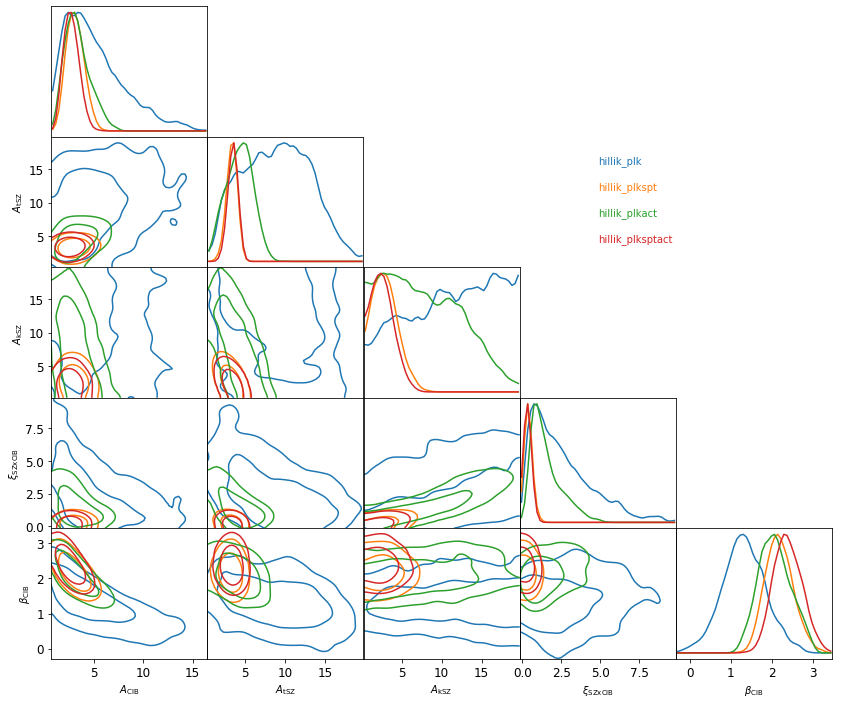

In [5]:
#extra-gal fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Alens

In [6]:
runnames = ['hillik_plk_Alens','hillik_plkact_Alens','hillik_plkspt_Alens','hillik_plksptact_Alens']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]

hillik_plk_Alens: 95949  201085  146245  136143 
hillik_plkact_Alens: 585323  522389  513689  544601 
hillik_plkspt_Alens: 473470  389992  535189  524216 
hillik_plksptact_Alens: 609168  605271  525366  854323 


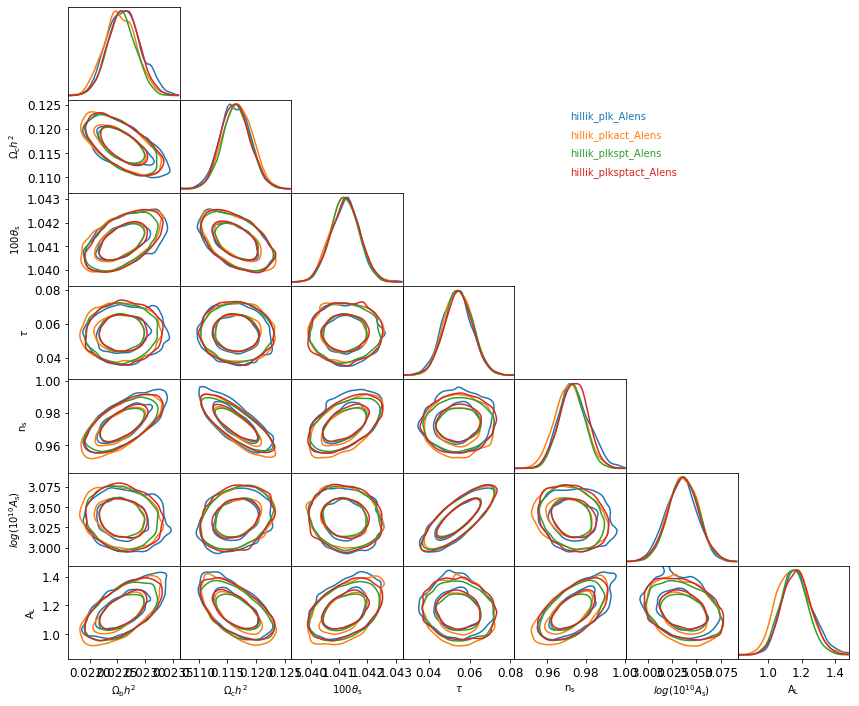

In [7]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA','Alens']
fig=MCtools.triangle( chains, listpar, labels=runnames, smooth=1.5)

In [8]:
print( "%35s %28s %28s %28s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

                   hillik_plk_Alens          hillik_plkact_Alens          hillik_plkspt_Alens       hillik_plksptact_Alens
ombh2           =  0.022616 +/- 0.000310  |   0.022539 +/- 0.000289  |   0.022572 +/- 0.000257  |   0.022617 +/- 0.000278
omch2           =  0.116271 +/- 0.002500  |   0.116778 +/- 0.002608  |   0.116546 +/- 0.002355  |   0.116351 +/- 0.002463
theta           =  1.041245 +/- 0.000499  |   1.041193 +/- 0.000523  |   1.041190 +/- 0.000479  |   1.041228 +/- 0.000516
tau             =  0.053918 +/- 0.007159  |   0.054388 +/- 0.006866  |   0.054652 +/- 0.006756  |   0.054586 +/- 0.006913
ns              =  0.973574 +/- 0.008140  |   0.971743 +/- 0.007664  |   0.972792 +/- 0.006439  |   0.973935 +/- 0.007097
logA            =  3.034763 +/- 0.015895  |   3.036291 +/- 0.015369  |   3.036782 +/- 0.015217  |   3.036259 +/- 0.015435
Alens           =  1.171272 +/- 0.091438  |   1.147816 +/- 0.095831  |   1.153631 +/- 0.079139  |   1.170138 +/- 0.084049


In [9]:
for i in range(len(chains)):
    m,s = MCtools.MaxPosterior( chains[i], 'Alens', symmetrical=True)
    print("%4.3f +/- %4.3f" % (m,s), "(%4.2fσ)" % ((m-1)/s), runnames[i])

1.171 +/- 0.091 (1.87σ) hillik_plk_Alens
1.148 +/- 0.096 (1.54σ) hillik_plkact_Alens
1.154 +/- 0.079 (1.94σ) hillik_plkspt_Alens
1.170 +/- 0.084 (2.02σ) hillik_plksptact_Alens


## Impact of Hillik

In [10]:
#SZ sector
runnames = ['hillik_spt','hillik_plksptact','spt_fixedLCDM']
spt = [MCtools.mergeMC( f"{DBdir}/{run}/mcmc", burnin=0.9, nelts=5000) for run in runnames]
for k,v in {'Atsz':'czero_tsz','Aksz':'czero_ksz','Acib':'czero_dg_cl','xi':'tsz_dg_cor'}.items(): spt[-1][k] = spt[-1][v]

hillik_spt: 822482  641454  614436  739384 
hillik_plksptact: 880813  1017840  939259  693479 
spt_fixedLCDM: 34761  45761  31241  46201 


Text(0, 0.5, 'D$^{kSZ}_{3000}\\quad(\\mu K^2)$')

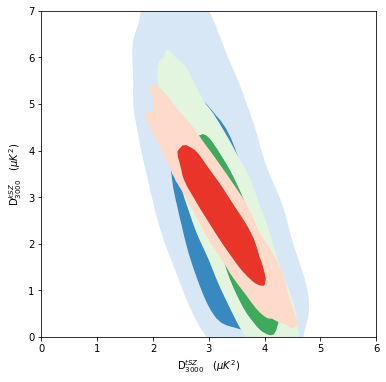

In [11]:
#Figure 3 [Reichard et al. 2020]
figure(figsize=(6,6))
for i,c in enumerate(['Blues','Greens','Reds']):
    MCtools.posterior2d(spt[i],'Atsz','Aksz', cmap=c, levels=[0.68,0.95], alpha=1)
xlim(0,6)
ylim(0,7)
xlabel('D$^{tSZ}_{3000}\quad(\mu K^2)$')
ylabel('D$^{kSZ}_{3000}\quad(\mu K^2)$')

Text(0, 6.2, 'tSZ')

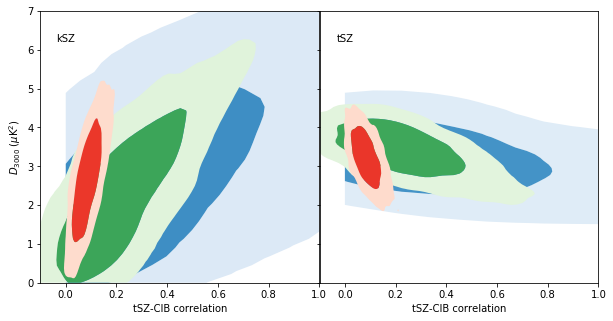

In [12]:
#Figure 4 Reichardt et al.
figure(figsize=(10,5))
subplot( 1, 2, 1)
for i,cm in enumerate(['Blues','Greens','Reds']):
    MCtools.posterior2d( spt[i], "xi", "Aksz", cmap=cm, levels=[0.68,0.95], alpha=1)
xlim(-0.1,1.)
ylim(0.,7)
ylabel( '$D_{3000}$ ($\\mu$K$^2$)')
xlabel( 'tSZ-CIB correlation')
text( 0, 6.2, 'kSZ', ha='center')
subplot( 1, 2, 2)
for i,cm in enumerate(['Blues','Greens','Reds']):
    MCtools.posterior2d( spt[i], "xi", "Atsz", cmap=cm, levels=[0.68,0.95], alpha=1)
subplots_adjust(wspace=0.001)
ylabel("")
gca().set_yticklabels([])
xlim(-0.1,1.)
ylim(0.,7)
xlabel( 'tSZ-CIB correlation')
text( 0, 6.2, 'tSZ', ha='center')

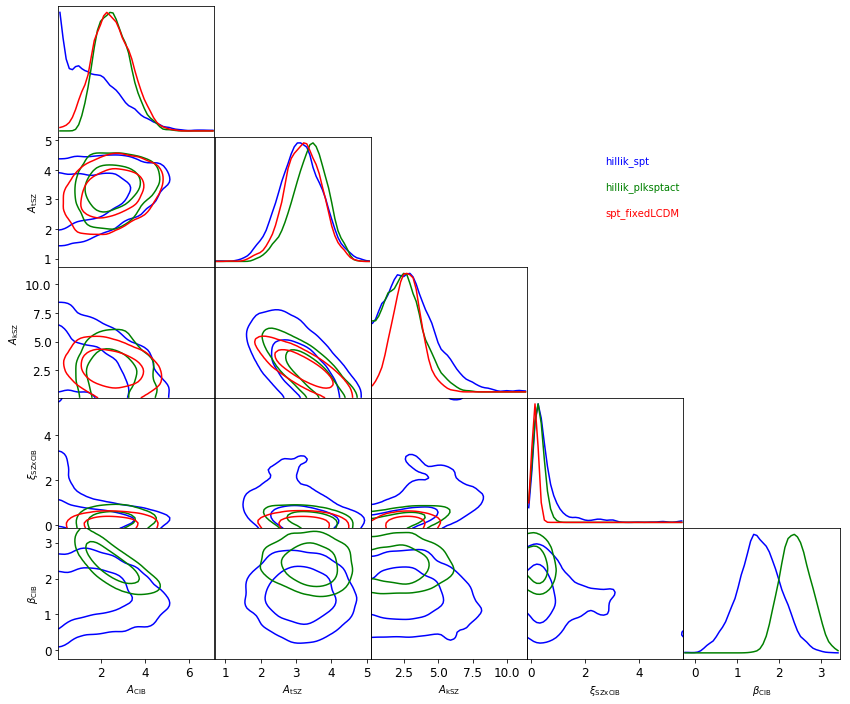

In [13]:
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( spt, listpar, labels=runnames, colors=['b','g','r'])

In [22]:
runnames = ['plk_spt_act','hillik_plksptact','plk_spt_act_Alens','hillik_plksptact_Alens']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=20000) for run in runnames]

plk_spt_act: 676200  586644  520265  501509 
hillik_plksptact: 249792  340726  316847  230354 
plk_spt_act_Alens: 484037  410584  519139  471037 
hillik_plksptact_Alens: 488608  461691  177371  282716 


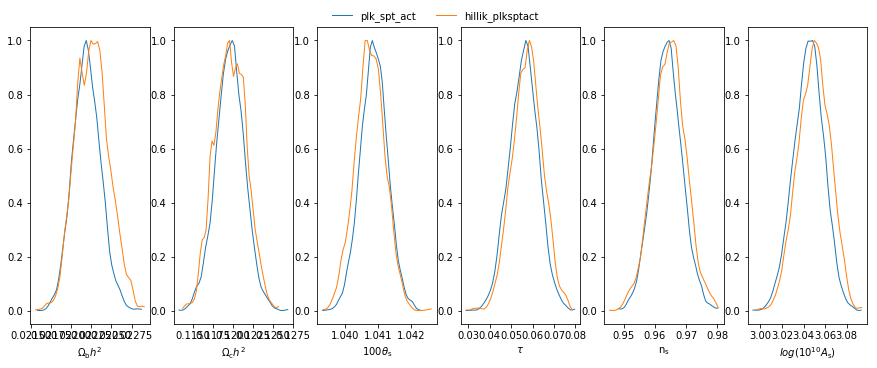

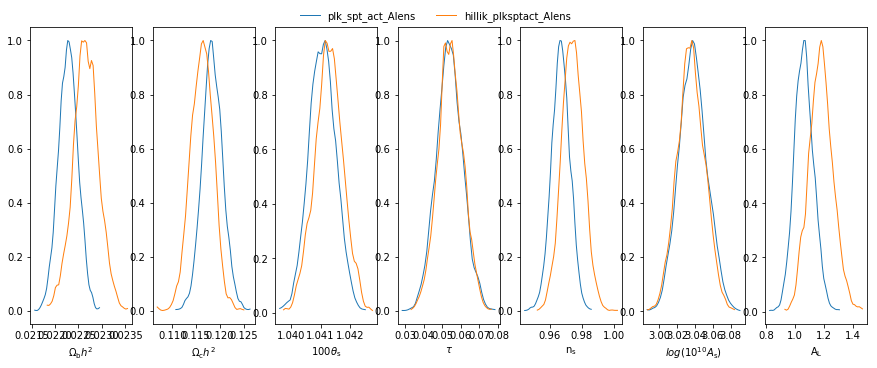

In [23]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA','Alens']
fig=MCtools.posterior1d( chains[:2], listpar[:-1], labels=runnames[:2], ncol=1, figsize=(15,5))
fig=MCtools.posterior1d( chains[2:], listpar, labels=runnames[2:], ncol=1, figsize=(15,5))

In [24]:
for par in listpar:
    m1,s1 = MCtools.MaxPosterior( chains[2], par, symmetrical=True)
    m2,s2 = MCtools.MaxPosterior( chains[3], par, symmetrical=True)
    print("%20s: %4.3f +/- %5.4f | %4.3f +/- %5.4f | (%4.2fσ)" % (par,m1,s1,m2,s2,(m1-m2)/s1))

               ombh2: 0.022 +/- 0.0002 | 0.023 +/- 0.0003 | (-1.81σ)
               omch2: 0.118 +/- 0.0021 | 0.116 +/- 0.0023 | (1.01σ)
               theta: 1.041 +/- 0.0005 | 1.041 +/- 0.0005 | (-0.48σ)
                 tau: 0.054 +/- 0.0070 | 0.054 +/- 0.0068 | (-0.08σ)
                  ns: 0.967 +/- 0.0057 | 0.974 +/- 0.0067 | (-1.28σ)
                logA: 3.038 +/- 0.0157 | 3.036 +/- 0.0155 | (0.13σ)
               Alens: 1.062 +/- 0.0657 | 1.178 +/- 0.0815 | (-1.77σ)


In [25]:
for i in range(2,len(chains)):
    m,s = MCtools.MaxPosterior( chains[i], 'Alens', symmetrical=True)
    print("%4.3f +/- %4.3f" % (m,s), "(%4.2fσ)" % ((m-1)/s), runnames[i])

1.062 +/- 0.066 (0.94σ) plk_spt_act_Alens
1.178 +/- 0.081 (2.18σ) hillik_plksptact_Alens


# Template tSZ

[]

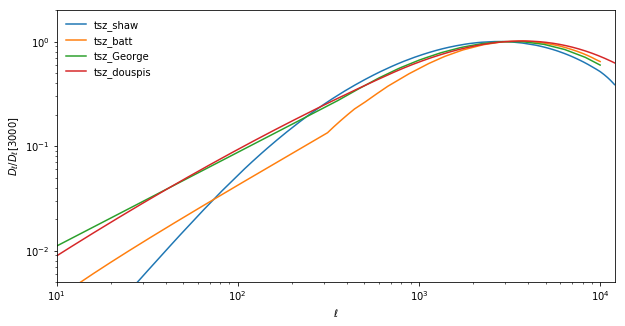

In [2]:
PKdir = "/sps/planck/Users/tristram/Soft/Hillik/modules/data"
tempnames = { "tsz_shaw":"dl_shaw_tsz_s10_153ghz_norm1_fake25000.txt",
             "tsz_batt":"dl_tsz_150_bat.dat",
             "tsz_George":"tsz_143_eps0.50.dat", 
             "tsz_douspis":"dl_tsz_MDRF.dat",}
plt.figure(figsize=(10,5))
for run in tempnames:
    l,cl = loadtxt( f"{PKdir}/foregrounds/{tempnames[run]}", unpack=True)
    plt.plot(l,cl/cl[l==3000], label=run)
plt.legend()
plt.ylim(5e-3,2)
plt.xlabel("$\ell$")
plt.ylabel("$D_\ell/D_\ell[3000]$")
plt.xlim(10,1.2e4)
plt.loglog()

In [3]:
runnames = ['tsz_shaw','tsz_batt','tsz_George','tsz_douspis']
chains = [MCtools.mergeMC( f"{DBdir}/hillik_plksptact_{run}/mcmc", burnin=0.9, nelts=10000) for run in runnames]

hillik_plksptact_tsz_shaw: 678303  585169  639159  555250 
hillik_plksptact_tsz_batt: 637642  659129  625642  674675 
hillik_plksptact_tsz_George: 633699  911867  662787  609127 
hillik_plksptact_tsz_douspis: 584829  636118  670955  657520 


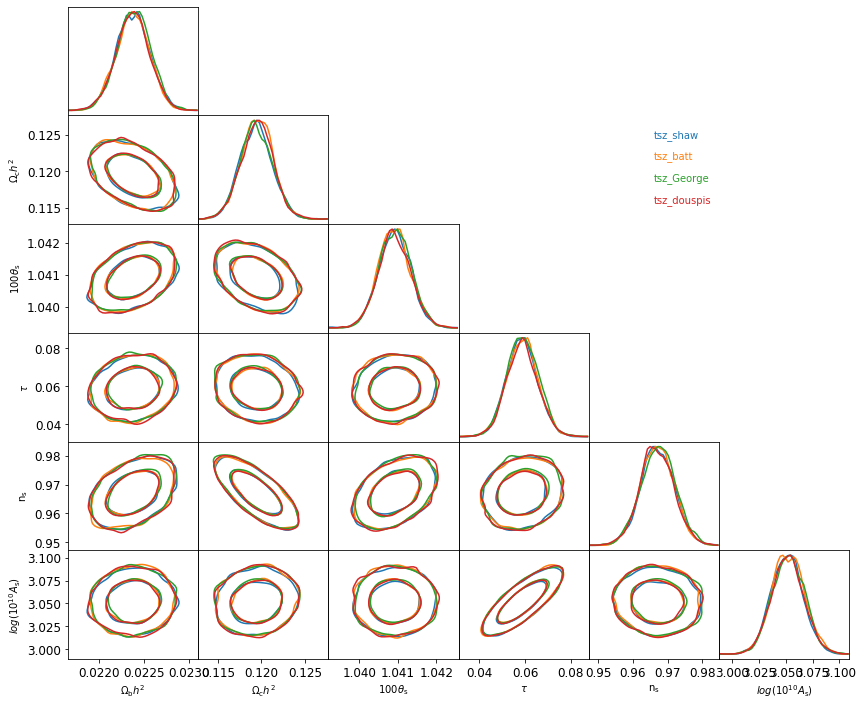

In [4]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

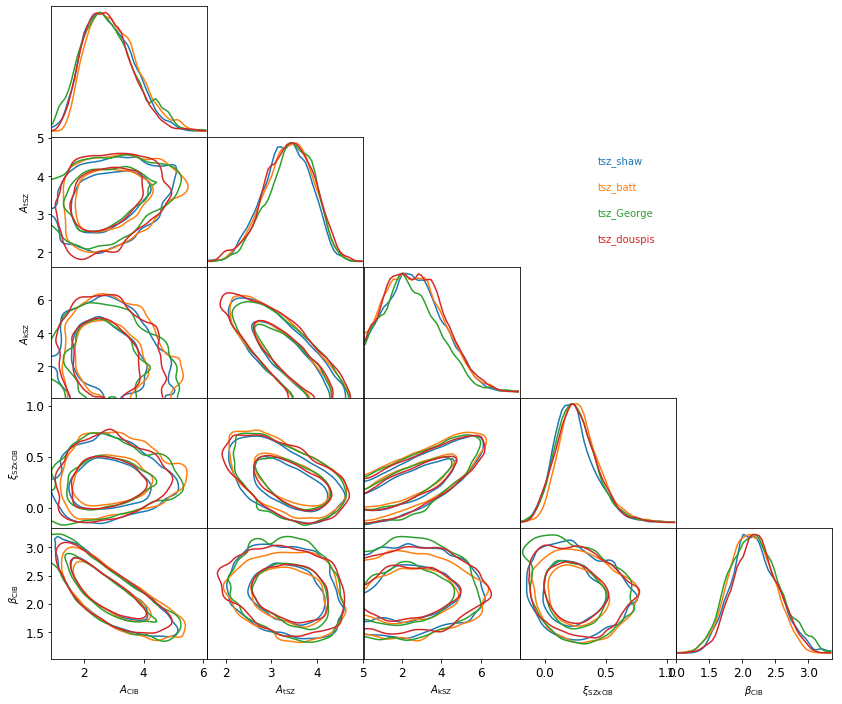

In [ ]:
#extra-gal fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

# Template kSZ

[]

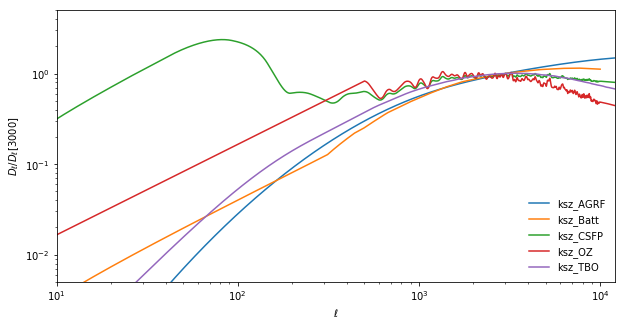

In [ ]:
PKdir = "/sps/planck/Users/tristram/Soft/Hillik/modules/data"
tempnames = { "ksz_AGRF":"dl_ksz_AGRF.dat",
             "ksz_Batt":"dl_ksz_bat.dat",
             "ksz_CSFP":"dl_ksz_CSFplusPATCHY_13sep2011_norm1_fake25000.txt", 
             "ksz_OZ":"dl_ksz_oz_patchy_nolowell_20110708_norm1_fake25000.txt",
             "ksz_TBO":"cl_tksz_148_tbo1.dat"}
plt.figure(figsize=(10,5))
for run in tempnames:
    l,cl = loadtxt( f"{PKdir}/foregrounds/{tempnames[run]}", unpack=True)
    plt.plot(l,cl/cl[l==3000], label=run)
plt.legend()
plt.ylim(5e-3,5)
plt.xlabel("$\ell$")
plt.ylabel("$D_\ell/D_\ell[3000]$")
plt.xlim(10,1.2e4)
plt.loglog()

In [2]:
runnames = ['ksz_AGRF','ksz_Batt','ksz_CSFP','ksz_OZ','ksz_TBO']
chains = [MCtools.mergeMC( f"{DBdir}/hillik_plksptact_{run}/mcmc", burnin=0.9, nelts=10000) for run in runnames]

hillik_plksptact_ksz_AGRF: 837580  818568  954677  643801 
hillik_plksptact_ksz_Batt: 573747  659738  900760  668619 
hillik_plksptact_ksz_CSFP: 923991  837769  743391  918876 
hillik_plksptact_ksz_OZ: 716889  949026  636384  789350 
hillik_plksptact_ksz_TBO: 727412  1106098  1000890  879509 


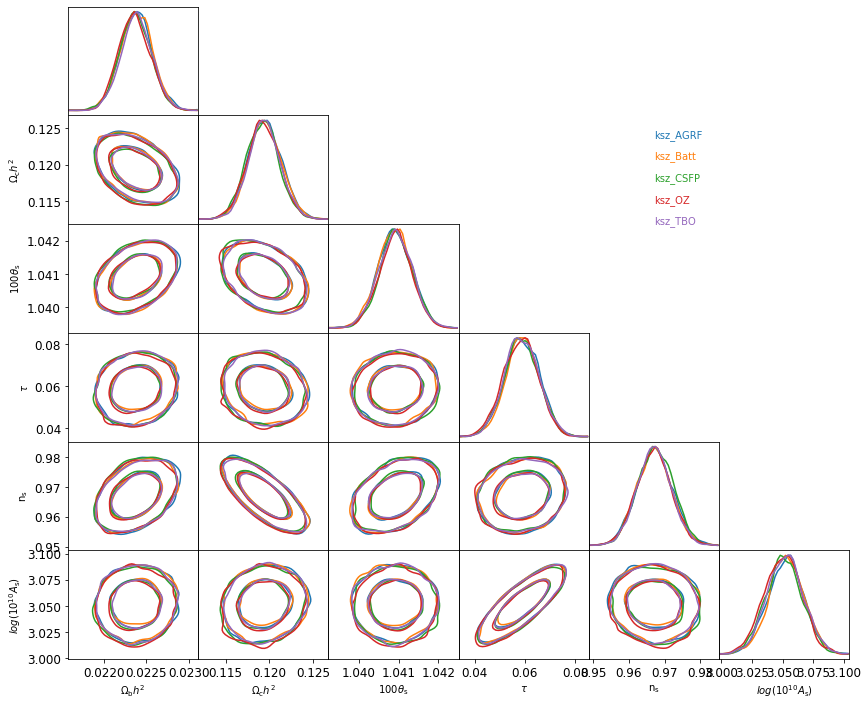

In [3]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

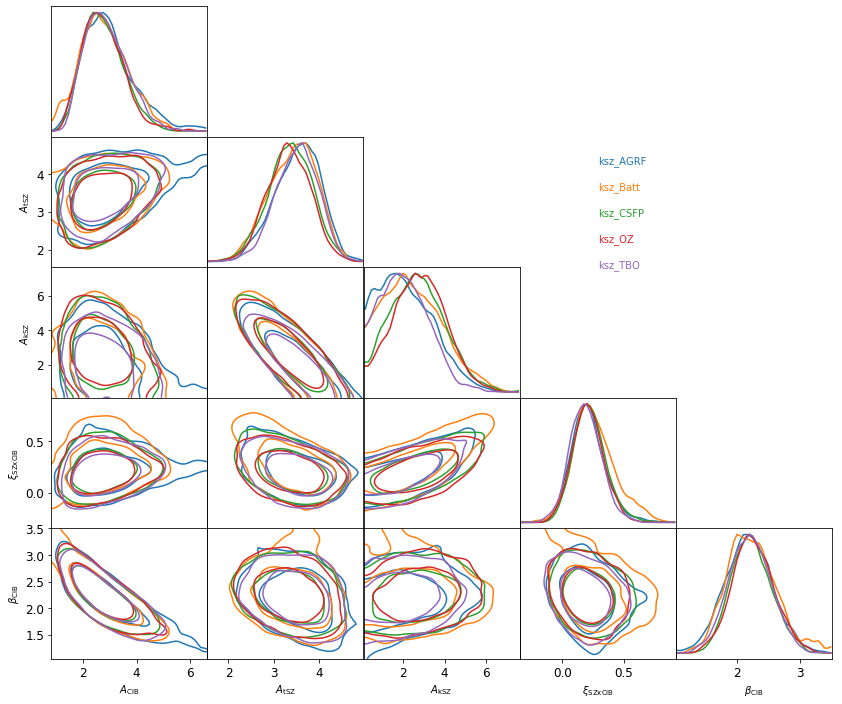

In [4]:
#extra-gal fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

# Template CIB

<span style="color:red"> **not yet converged !!** </span>

[]

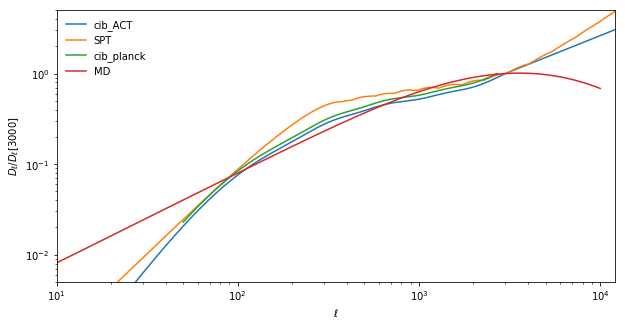

In [109]:
PKdir = "/sps/planck/Users/tristram/Soft/Hillik/modules/data"
tempnames = { "cib_ACT":"cib_extra.dat",  #ACT
             "cib_1h":"dl_cib_1halo_norm1_25000.txt", 
             "cib_2h":"dl_cib_2halo_norm1_25000.txt"}
plt.figure(figsize=(10,5))
#ACT
l,cl = loadtxt( f"{PKdir}/foregrounds/cib_extra.dat", unpack=True)
plt.plot(l,cl/cl[l==3000], label="cib_ACT")
#SPT
l1,cl1 = loadtxt( f"{PKdir}/foregrounds/dl_cib_1halo_norm1_25000.txt", unpack=True)
l2,cl2 = loadtxt( f"{PKdir}/foregrounds/dl_cib_2halo_norm1_25000.txt", unpack=True)
plot( l1, (cl1+cl2)/(cl1+cl2)[l1==3000], label="SPT")
#PLK
cib = fits.getdata( f"{PKdir}/planck_2020/hillipop/foregrounds/CIB_planck_npipe_model_v3_217x217.fits")
cl = cib.ELL*(cib.ELL+1)/2/pi*(cib.CL1HALO+cib.CL2HALO)
plt.plot( cib.ELL, cl/cl[-1], label="cib_planck")
#MD
l,cl1,cl2,_ = loadtxt(f"{PKdir}/foregrounds/ClSZ_poiss_corr_MD2_cppp_bestCl_NILC_extra12_cibps_lmax10000.res",unpack=True)
plot( l, (cl1+cl2)/(cl1+cl2)[l==3000], label="MD")
#plt.plot( l, cl1/cl1[l==3000], label="cib_douspis")
#plt.plot( l, cl2/cl2[l==3000], label="cib_douspis")
plt.legend()
plt.ylim(5e-3,5)
plt.xlabel("$\ell$")
plt.ylabel("$D_\ell/D_\ell[3000]$")
plt.xlim(10,1.2e4)
plt.loglog()